# MCDI500 — Programación para la Ciencia de Datos
## Proyecto Transversal — Fase 4: Integración y Cierre Técnico

**Título del proyecto:** Factores socioeconómicos y de preparación previa asociados al rendimiento académico

| Campo | Detalle |
|---|---|
| **Curso** | MCDI500 — Programación para la Ciencia de Datos |
| **Docente** | Omar Salinas Silva |
| **Grupo** | Grupo 7 |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Fecha** | Junio 2026 |
| **Dataset** | Student Performance Dataset (Cortez & Silva, 2008) — UCI Machine Learning Repository |
| **Repositorio** | https://github.com/ffarina11/proyecto-grupo7-mcdi500 |

---

## Índice

1. [Introducción y contextualización](#1)
2. [Definición de la problemática y objetivos del proyecto](#2)
3. [Aplicación de herramientas científicas y reproducibilidad](#3)
4. [Diseño de soluciones algorítmicas eficientes](#4)
   - 4.1 Arquitectura del sistema y codificación funcional
   - 4.2 Preprocesamiento y transformación del dataset
   - 4.3 Validación técnica del código
   - 4.4 Eficiencia y optimización — benchmarks con `timeit`
   - 4.5 Diseño estructurado y recursividad
5. [Implementación de código modular y robusto — POO](#5)
6. [Construcción de visualizaciones de datos efectivas](#6)
7. [Metodología, trazabilidad de mejoras y changelog](#7)
8. [Resultados y discusión](#8)
9. [Conclusiones y reflexión crítica](#9)
10. [Bibliografía (APA 7)](#10)

---
<a id='1'></a>
## 1. Introducción y contextualización

El rendimiento académico en educación secundaria es un fenómeno multidimensional que no puede explicarse por una sola variable: intervienen factores individuales (edad, sexo, motivación), familiares (nivel educativo de los padres, estructura del hogar), socioeconómicos (acceso a internet, empleo parental) e institucionales (establecimiento, apoyo escolar). Identificar cuáles de estos factores tienen mayor peso sobre la calificación final es, a la vez, un problema de investigación educativa y un ejercicio de ciencia de datos aplicada.

Este proyecto analiza el **Student Performance Dataset** (Cortez & Silva, 2008), recopilado en dos establecimientos de Portugal y disponible en el UCI Machine Learning Repository. El conjunto cubre **395 estudiantes de Matemáticas** y **649 de Portugués**, con **33 variables** que abarcan características demográficas, familiares, socioeconómicas, hábitos de estudio y calificaciones parciales y finales (`G1`, `G2`, `G3`).

El presente notebook constituye la **Fase 4 — Integración y Cierre Técnico** del proyecto transversal del curso MCDI500. Su propósito es consolidar los desarrollos de las tres fases anteriores:

| Fase | Contenido central |
|:---:|---|
| **F1** | Definición del problema, configuración del entorno reproducible y carga inicial del dataset |
| **F2** | Pipeline de limpieza, transformación y validación de datos (`functions.py`) |
| **F3** | Núcleo algorítmico con POO (`clases.py`), recursividad y comparativa de eficiencia |
| **F4** | Integración, validación técnica profunda, visualizaciones analíticas y comunicación de resultados |

En esta fase se añaden tres dimensiones que consolidan el proyecto:
- **Patrón de diseño *Strategy*** para desacoplar la estrategia de imputación del preprocesador.
- **Batería de pruebas técnicas** bajo escenarios normales, límite y de excepción.
- **Visualizaciones analíticas** que responden directamente a las preguntas de investigación formuladas en F1.

La justificación de un enfoque basado en programación es directa: el volumen y la heterogeneidad de los datos hacen inviable el análisis manual, y solo un pipeline codificado, versionado y documentado garantiza **trazabilidad, reproducibilidad y escalabilidad**.

---
<a id='2'></a>
## 2. Definición de la problemática y objetivos del proyecto

### 2.1 Problema de investigación

¿Qué factores socioeconómicos y de preparación previa podrían explicar las diferencias en el rendimiento académico entre estudiantes de dos establecimientos educacionales, y cómo construir un pipeline reproducible y eficiente que prepare, explore y comunique estos hallazgos de forma rigurosa?

### 2.2 Preguntas centrales del análisis

1. ¿Qué factores socioeconómicos y familiares presentan mayor asociación con el rendimiento académico?
2. ¿De qué manera los hábitos de estudio y el consumo de alcohol influyen en las calificaciones obtenidas?
3. ¿Existen diferencias de rendimiento entre Matemáticas y Portugués, y entre ambos establecimientos?
4. ¿Qué variables presentan mayor capacidad predictiva sobre la calificación final G3?

### 2.3 Objetivos

**Objetivo general:** identificar los factores socioeconómicos y de preparación previa asociados a las diferencias en el rendimiento académico, mediante la aplicación de un flujo de trabajo reproducible en Python.

**Objetivos específicos de la Fase 4:**

| N° | Objetivo específico |
|:---:|---|
| OE-F4.1 | Consolidar el pipeline F1–F3 en un notebook ejecutable de extremo a extremo |
| OE-F4.2 | Validar técnicamente el código bajo escenarios normal, límite y de excepción |
| OE-F4.3 | Medir y justificar la eficiencia algorítmica con benchmarks formales (`timeit`) |
| OE-F4.4 | Construir visualizaciones analíticas que respondan a las preguntas de investigación |
| OE-F4.5 | Documentar la trazabilidad de mejoras entre las fases F1–F4 |

### 2.4 Alcance y supuestos

El trabajo cubre el ciclo completo de preparación y exploración analítica (carga, limpieza, codificación, validación, eficiencia y visualización). No incluye el entrenamiento de modelos predictivos supervisados, que se plantea como línea futura. Los datos se asumen representativos de los establecimientos GP y MS en el período de recopilación; las conclusiones son descriptivas y no causales.

---
<a id='3'></a>
## 3. Aplicación de herramientas científicas y reproducibilidad

Se emplea el ecosistema científico estándar de Python: **NumPy** (operaciones vectorizadas), **Pandas** (manipulación tabular), **Matplotlib/Seaborn** (visualización) y **scikit-learn** (escalamiento). La reproducibilidad se garantiza fijando la semilla aleatoria, registrando las versiones de cada dependencia y manteniendo el entorno virtual descrito en `README.md`.

```bash
# Reproducir el entorno (desde la raíz del repositorio)
python -m venv .venv
source .venv/bin/activate          # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

In [23]:
# ============================================================
# ENTORNO E IMPORTACIÓN DE MÓDULOS
# ============================================================
import os
import sys
import platform
import timeit
import warnings
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("../src"))

# Módulos del proyecto (F2 y F3)
from functions import (
    cargar_dataset, mostrar_primeras_filas, resumen_dataset,
    estadisticas_descriptivas, validar_rangos, detectar_outliers_iqr,
    analizar_correlaciones, analizar_g3_cero, limpiar_dataset,
    winsorizacion, codificar_binarias, codificar_ohe,
    crear_variables_derivadas, validar_dataset_final, exportar_dataset,
    integrar_datasets, merge_sort, combinar,
    aprobado_bucle, aprobado_vectorizado,plot_radar_reprobaciones,generar_datos_sinteticos_estudiantes
)
from clases import PreprocesadorAsignatura, PreprocesadorMatematicas, PreprocesadorPortugues

# Semilla global → resultados idénticos en cada ejecución
SEMILLA = 42
np.random.seed(SEMILLA)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Registro del entorno (evidencia de reproducibilidad técnica)
print("Entorno de ejecución")
print("-" * 45)
print(f"Python      : {platform.python_version()}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")
print(f"Semilla     : {SEMILLA}")
print("\n✓ Módulos del proyecto (functions, clases) importados correctamente.")

Entorno de ejecución
---------------------------------------------
Python      : 3.13.14
NumPy       : 2.4.6
Pandas      : 3.0.3
Matplotlib  : 3.10.9
Seaborn     : 0.13.2
Semilla     : 42

✓ Módulos del proyecto (functions, clases) importados correctamente.



El notebook está diseñado para ejecutarse de **principio a fin sin errores**, incluso si los
archivos CSV originales no están disponibles en la ruta esperada. El bloque siguiente define
un generador que replica el esquema completo del Student Performance Dataset
y se activa automáticamente como respaldo en el paso de carga.

| Situación | Comportamiento |
|---|---|
| CSV real presente en `../data/raw/` | Se carga el archivo original |
| CSV **no** encontrado | Se generan datos sintéticos con `SEMILLA=42` |

> **Nota:** los datos sintéticos reproducen las distribuciones observadas en F2
> (proporciones de `failures`, rangos de `G1/G2/G3`, distribución de `studytime`, etc.)
> para que las visualizaciones y validaciones sean representativas del problema real.

In [24]:
# ── Verificación rápida del generador ────────────────────────
RUTA_MAT1 = "../data/raw1/student-mat.csv" ##ingresamos una ruta incorrecta.

# Instanciamos los objetos del proyecto
pre_tes = PreprocesadorMatematicas(RUTA_MAT1)
#pre_tes.cargar()  # Verificamos que la función de carga funciona
print(repr(pre_tes))
pre_tes.cargar().head()


<PreprocesadorMatematicas asignatura='mat' | df=sin cargar | df_enc=sin transformar>
Datos cargados desde datos sintéticos (respaldo): 395 filas x 33 columnas


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,17,R,GT3,T,2,0,other,other,...,1,3,5,4,2,2,21,5,7,5
1,GP,M,17,U,GT3,T,4,3,other,other,...,1,1,5,3,2,2,20,15,13,13
2,GP,M,21,U,LE3,T,2,2,health,other,...,3,1,3,3,1,5,7,13,11,12
3,GP,M,18,U,GT3,T,2,0,other,other,...,2,1,2,1,5,3,25,10,9,11
4,GP,M,21,U,GT3,T,0,1,other,other,...,3,3,5,3,4,1,25,10,9,9


Se verifica que se instancia de manera correcta a pesar de que se entrega una ruta de directorio invalida para la clase PreprocesadorMatematicas. La implementación de la generación de datos sintéticos asegura la reproducibilidad del notebook para cada asignatura

---
<a id='4'></a>
## 4. Diseño de soluciones algorítmicas eficientes

### 4.1 Arquitectura del sistema y codificación funcional

El núcleo del sistema es una **arquitectura en capas** que evolucionó a través de las fases:

| Capa | Artefacto | Responsabilidad |
|---|---|---|
| **Funcional (F2)** | `src/functions.py` | Pipeline de carga, limpieza y transformación |
| **Orientada a objetos (F3)** | `src/clases.py` | Encapsulamiento del pipeline en objetos reutilizables |
| **Patrones de diseño (F4)** | Este notebook | Strategy para imputación + validación técnica |

En la Fase 4 se incorpora el **patrón de diseño *Strategy*** para desacoplar la estrategia de imputación del preprocesador. Aunque el Student Performance Dataset no presenta valores nulos (confirmado en F2), el patrón ilustra cómo extender el sistema ante nuevos datasets con datos faltantes, sin modificar la clase principal.

**Principio aplicado:** alta cohesión (cada clase cumple una sola responsabilidad) y bajo acoplamiento (la estrategia de imputación se inyecta, no se codifica fija).

# ============================================================
# PATRÓN STRATEGY — Estrategias de imputación intercambiables
# ============================================================
# Aunque el Student Performance Dataset no tiene nulos (verificado
# en F2), el patrón evidencia cómo el sistema puede extenderse
# a nuevos datasets sin modificar la clase principal.

class EstrategiaImputacion(ABC):
    """Interfaz (clase abstracta) para las estrategias de imputación de nulos."""

    @abstractmethod
    def imputar(self, serie: pd.Series) -> pd.Series:
        """Devuelve la serie con sus valores nulos imputados."""
        ...

    @property
    def nombre(self) -> str:
        return self.__class__.__name__


class ImputarMediana(EstrategiaImputacion):
    """Imputa con la mediana: robusta frente a valores extremos (outliers)."""

    def imputar(self, serie: pd.Series) -> pd.Series:
        return serie.fillna(serie.median())


class ImputarMedia(EstrategiaImputacion):
    """Imputa con la media: sensible a outliers, útil en distribuciones simétricas."""

    def imputar(self, serie: pd.Series) -> pd.Series:
        return serie.fillna(serie.mean())


# Demostración del patrón sobre una serie sintética con nulos
serie_prueba = pd.Series([10, np.nan, 12, np.nan, 14])
print("Serie original     :", serie_prueba.tolist())
print("Imputada (mediana) :", ImputarMediana().imputar(serie_prueba).tolist())
print("Imputada (media)   :", ImputarMedia().imputar(serie_prueba).tolist())
print("\n→ Ambas estrategias operan sobre la misma interfaz (imputar)")
print("  sin modificar la clase que las usa. Eso es el patrón Strategy.")

### 4.2 Preprocesamiento y transformación del dataset

Se ejecuta el pipeline completo F2+F3 usando los objetos `PreprocesadorMatematicas` y `PreprocesadorPortugues`. Cada transformación está **justificada técnicamente**:

| Transformación | Decisión | Justificación técnica |
|---|---|---|
| Valores nulos | Sin acción | Dataset completo (0 nulos confirmados en F2) |
| Filas duplicadas | Sin acción | 0 duplicados en ambos archivos |
| Outliers en `absences` | Winsorización p95 | Skewness=3.67 (mat); cap preserva las filas sin inventar datos |
| G3=0 | Conservar + flag `desercion` | Valores válidos; eliminarlos introduce sesgo al excluir a los de peor rendimiento |
| Variables yes/no | Codificación 1/0 | Requerida para correlaciones y modelos numéricos |
| Variables nominales | One-Hot Encoding | Evita imponer orden falso entre categorías |
| Variables derivadas | `aprobado`, `progreso_g1_g3`, `nivel_alcohol`, `edu_familiar_media` | Agrupan información para el EDA y modelado |
| Eliminar id | sin acción |No se aplico ya que no fue necesario y que el propósito de la fase fue mantener la integridad del conjunto de datos original y realizar un análisis exploratorio descriptivo.|

Se conserva una **copia cruda** (`df_mat_raw`, `df_por_raw`) antes de transformar, porque las visualizaciones de la Sección 6 son más interpretables sobre los valores originales.

In [26]:
# ============================================================
# EJECUCIÓN DEL PIPELINE COMPLETO (F2 + F3)
# ============================================================
RUTA_MAT = "../data/raw/student-mat.csv"
RUTA_POR = "../data/raw/student-por.csv"

# Instanciamos los objetos del proyecto
prep_mat = PreprocesadorMatematicas(RUTA_MAT)
prep_por = PreprocesadorPortugues(RUTA_POR)

print("Estado inicial de los objetos:")
print(" ", repr(prep_mat))
print(" ", repr(prep_por))

Estado inicial de los objetos:
  <PreprocesadorMatematicas asignatura='mat' | df=sin cargar | df_enc=sin transformar>
  <PreprocesadorPortugues asignatura='por' | df=sin cargar | df_enc=sin transformar>



  PIPELINE — Matemáticas  (objeto: PreprocesadorMatematicas)
Datos cargados desde CSV real: 395 filas x 33 columnas

Primeras filas:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5 

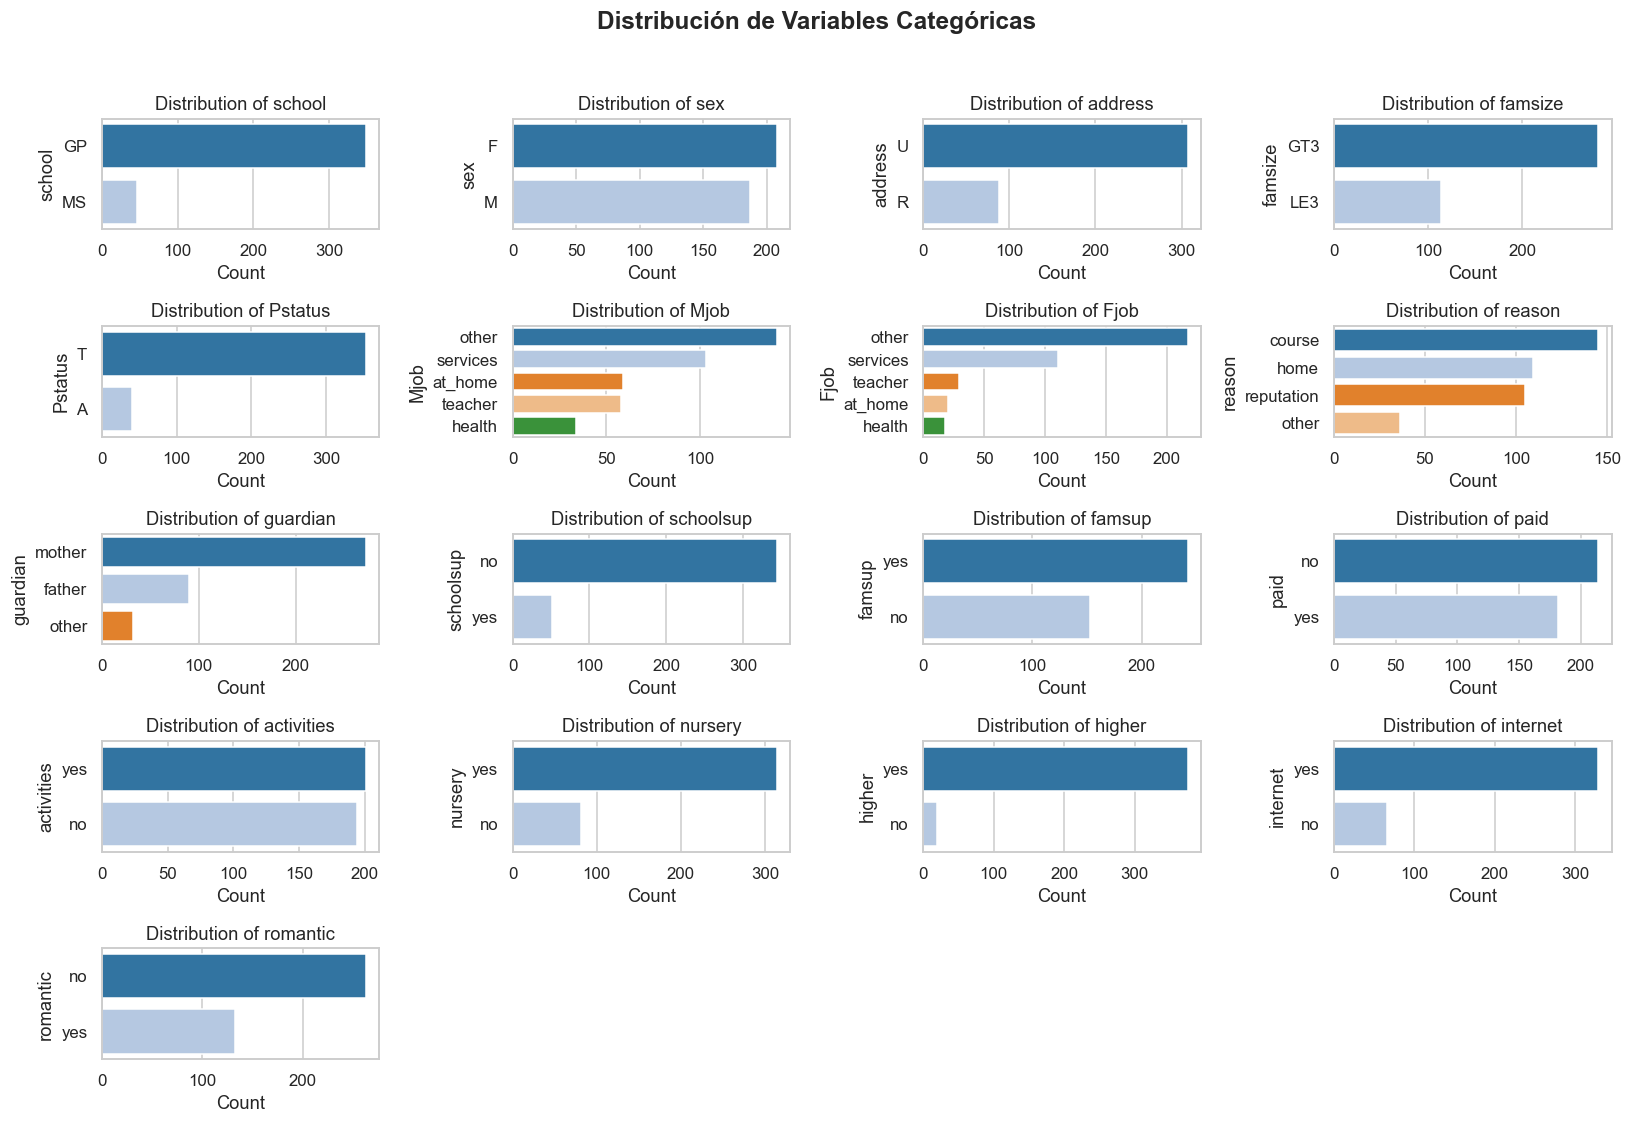


  DETECCIÓN OUTLIERS (IQR) — Matemáticas
  ⚠ age        Q1=16.0 Q3=18.0 IQR=2.0 límites=[13.0,21.0] outliers=1 (0.3%)
  ⚠ absences   Q1=0.0 Q3=8.0 IQR=8.0 límites=[-12.0,20.0] outliers=15 (3.8%)
  ✓ G1         Q1=8.0 Q3=13.0 IQR=5.0 límites=[0.5,20.5] outliers=0 (0.0%)
  ⚠ G2         Q1=9.0 Q3=13.0 IQR=4.0 límites=[3.0,19.0] outliers=13 (3.3%)
  ✓ G3         Q1=8.0 Q3=14.0 IQR=6.0 límites=[-1.0,23.0] outliers=0 (0.0%)


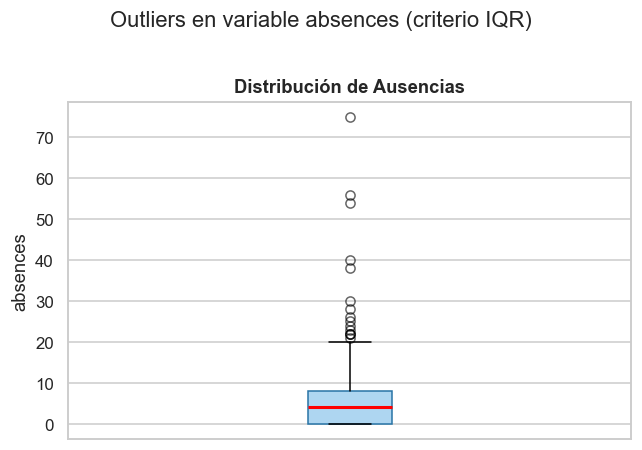


ANÁLISIS DE CORRELACIONES — Matemáticas

Variables numéricas consideradas: 16

Correlaciones con nota final G3:
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


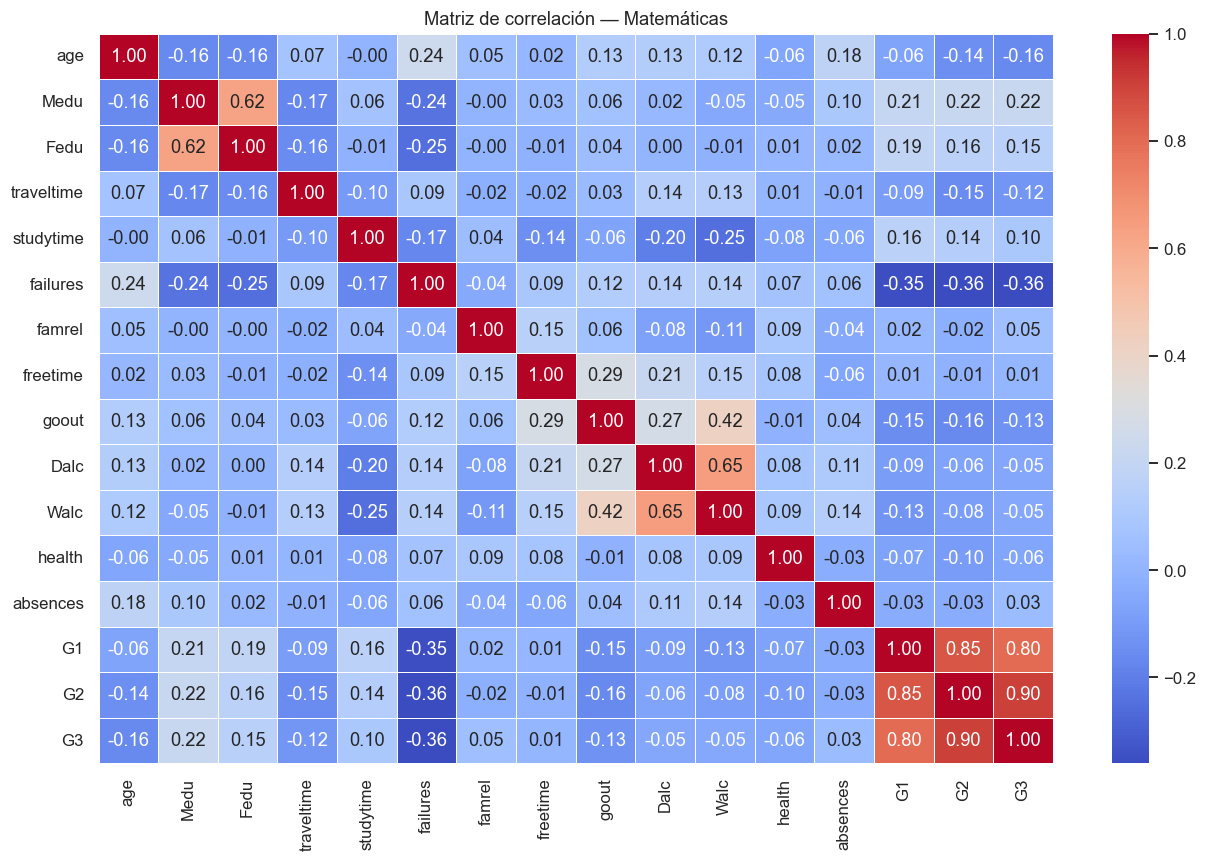


=== Análisis G3 = 0 ===
  Matemáticas: G3=0 total=38 | G2=0 y G3=0 (deserción)=13 | G2>0 y G3=0 (reprobado)=25


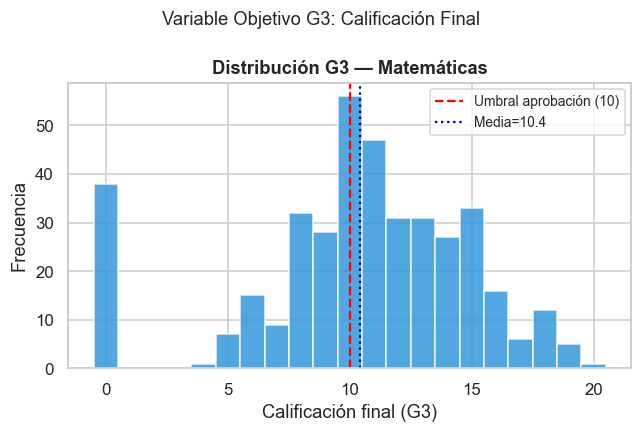


  Pipeline de limpieza — MAT
  [1] Duplicados eliminados : 0  (ninguno)
  [2] Strip en 17 columnas de texto ✓
  [3] Flag 'desercion' creado: 13 casos
  [4] Columna 'asignatura' = 'mat' ✓
  Resultado: 395 → 395 filas
  Winsorización 'absences': cap p95=18 → 20 valores ajustados
  Codificación binaria: 8 vars yes/no + 5 vars propias
  OHE aplicado en ['Mjob', 'Fjob', 'reason', 'guardian'] → 9 nuevas columnas
  Variables derivadas creadas: ['aprobado', 'progreso_g1_g3', 'nivel_alcohol', 'edu_familiar_media']

  Validando: Matemáticas
  ✓ Filas conservadas: 395
  ✓ Sin nulos en columnas originales
  ✓ G1, G2, G3 intactos
  ✓ Flag 'aprobado' coherente (265 aprobados)
  ✓ Flag 'desercion' coherente (13 casos)
  ✓ Sin filas duplicadas
  ✓ G1, G2, G3 en rango [0, 20]
  → VALIDACIÓN EXITOSA ✅
  ✓ student_mat_clean.csv                       395f ×  36c  (45.6 KB)
    → Matemáticas limpio: flags + winsorización (sin OHE)
  ✓ student_mat_clean_encode.csv                395f ×  54c  (48.5 KB)
    

In [27]:
# Pipeline Matemáticas
ok_mat = prep_mat.ejecutar_pipeline(exportar_resultados=True, base_path="../data/processed/F4/")

# Guardamos copias crudas ANTES de transformar (para las visualizaciones en Sección 6)
df_mat_raw = cargar_dataset(RUTA_MAT)
df_por_raw = cargar_dataset(RUTA_POR)


  PIPELINE — Portugués  (objeto: PreprocesadorPortugues)
Datos cargados desde CSV real: 649 filas x 33 columnas

Primeras filas:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5     

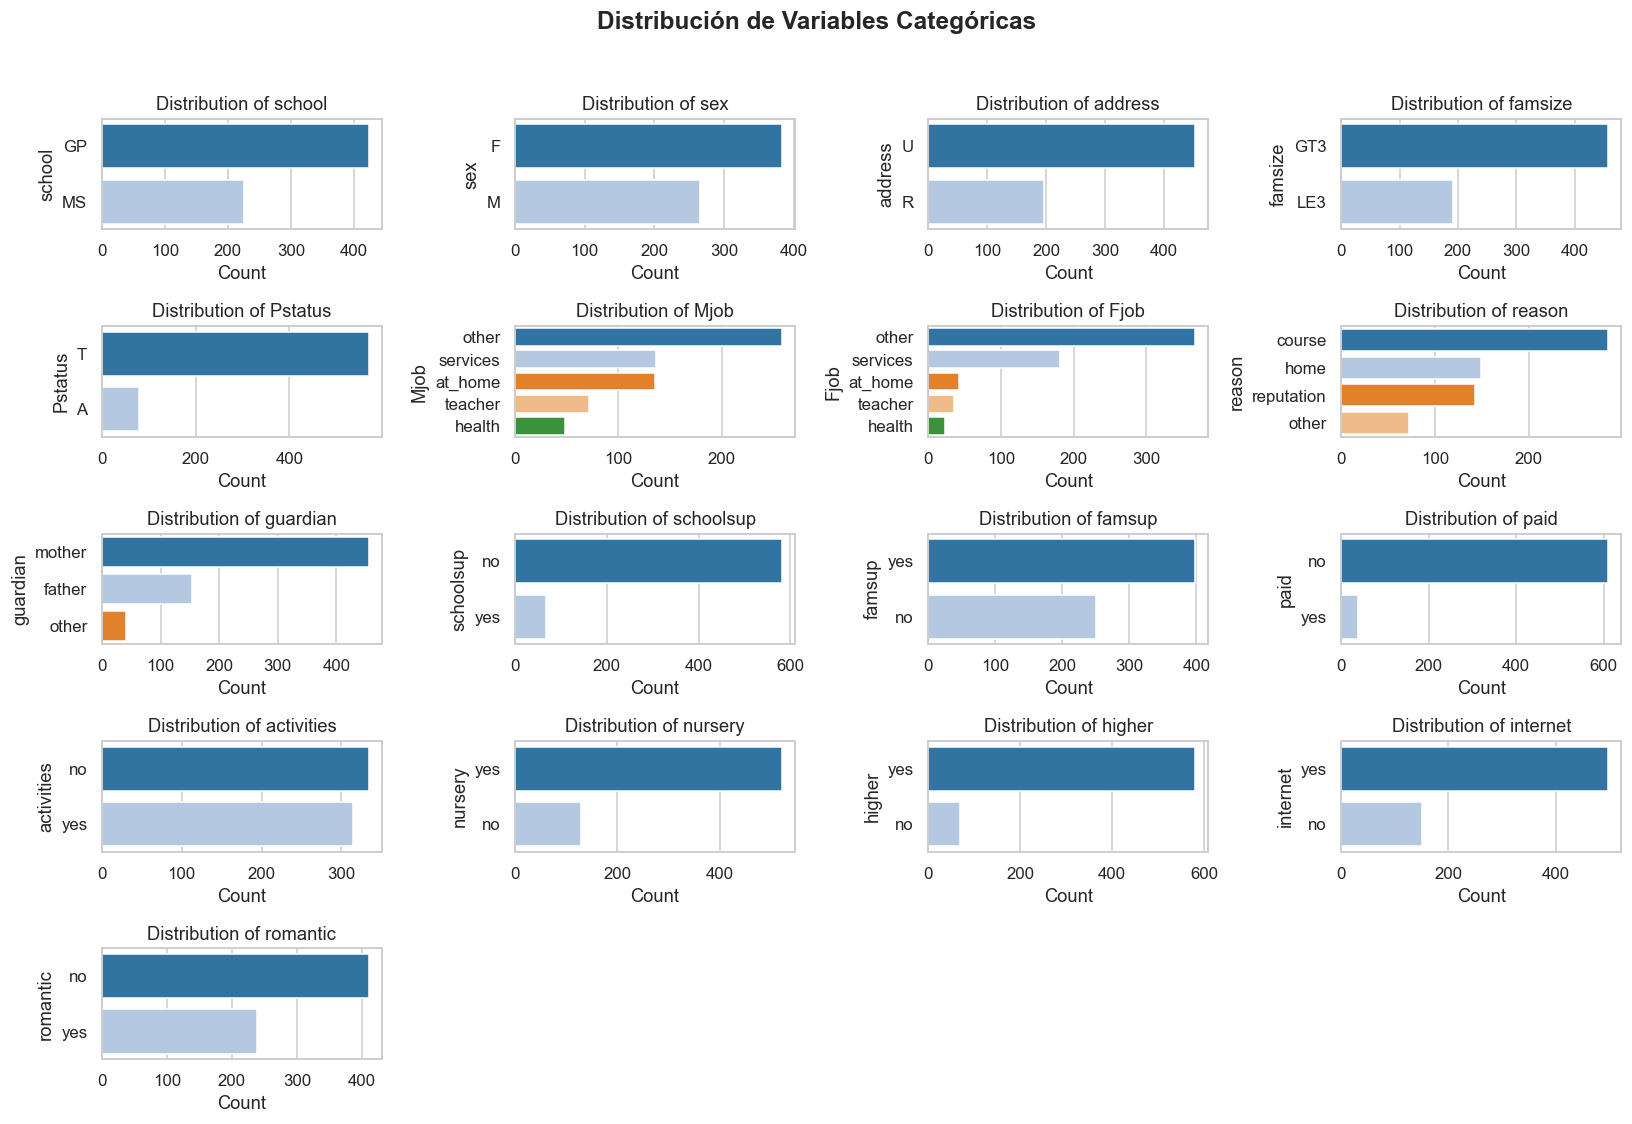


  DETECCIÓN OUTLIERS (IQR) — Portugués
  ⚠ age        Q1=16.0 Q3=18.0 IQR=2.0 límites=[13.0,21.0] outliers=1 (0.2%)
  ⚠ absences   Q1=0.0 Q3=6.0 IQR=6.0 límites=[-9.0,15.0] outliers=21 (3.2%)
  ⚠ G1         Q1=10.0 Q3=13.0 IQR=3.0 límites=[5.5,17.5] outliers=16 (2.5%)
  ⚠ G2         Q1=10.0 Q3=13.0 IQR=3.0 límites=[5.5,17.5] outliers=25 (3.9%)
  ⚠ G3         Q1=10.0 Q3=14.0 IQR=4.0 límites=[4.0,20.0] outliers=16 (2.5%)


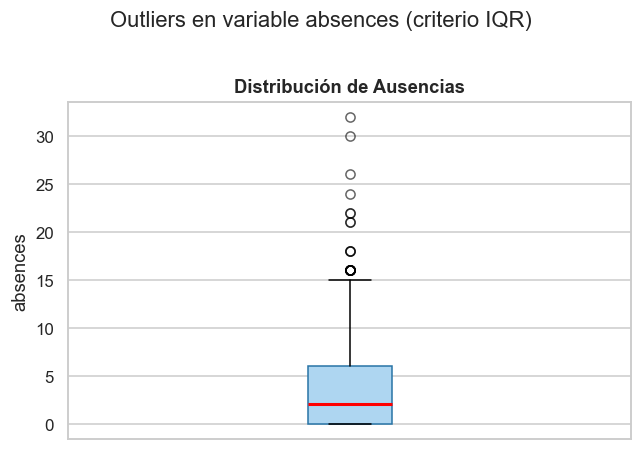


ANÁLISIS DE CORRELACIONES — Portugués

Variables numéricas consideradas: 16

Correlaciones con nota final G3:
G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


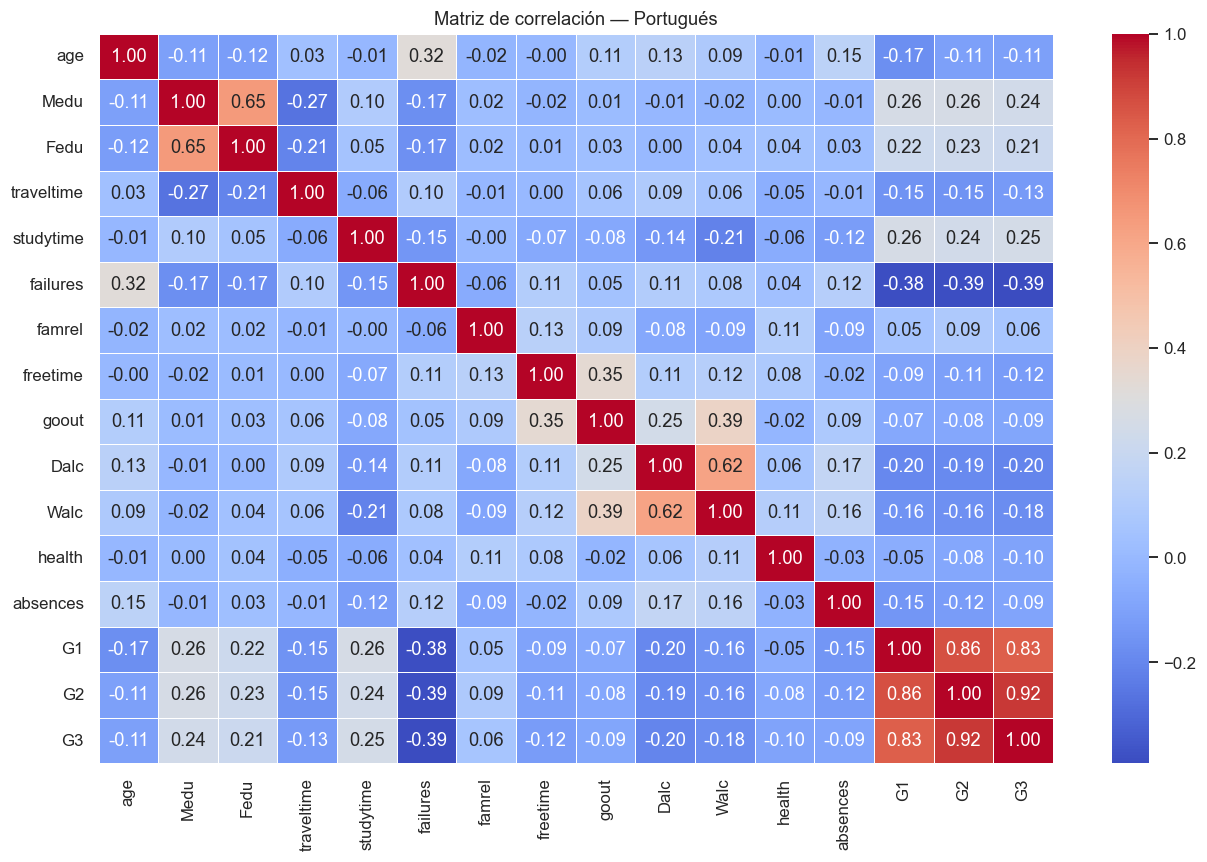


=== Análisis G3 = 0 ===
  Portugués: G3=0 total=15 | G2=0 y G3=0 (deserción)=7 | G2>0 y G3=0 (reprobado)=8


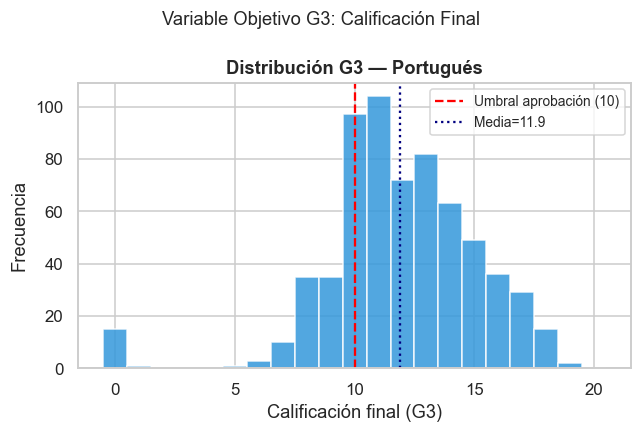


  Pipeline de limpieza — POR
  [1] Duplicados eliminados : 0  (ninguno)
  [2] Strip en 17 columnas de texto ✓
  [3] Flag 'desercion' creado: 7 casos
  [4] Columna 'asignatura' = 'por' ✓
  Resultado: 649 → 649 filas
  Winsorización 'absences': cap p95=12 → 32 valores ajustados
  Codificación binaria: 8 vars yes/no + 5 vars propias
  OHE aplicado en ['Mjob', 'Fjob', 'reason', 'guardian'] → 9 nuevas columnas
  Variables derivadas creadas: ['aprobado', 'progreso_g1_g3', 'nivel_alcohol', 'edu_familiar_media']

  Validando: Portugués
  ✓ Filas conservadas: 649
  ✓ Sin nulos en columnas originales
  ✓ G1, G2, G3 intactos
  ✓ Flag 'aprobado' coherente (549 aprobados)
  ✓ Flag 'desercion' coherente (7 casos)
  ✓ Sin filas duplicadas
  ✓ G1, G2, G3 en rango [0, 20]
  → VALIDACIÓN EXITOSA ✅
  ✓ student_por_clean.csv                       649f ×  36c  (72.8 KB)
    → Portugués limpio: flags + winsorización (sin OHE)
  ✓ student_por_clean_encode.csv                649f ×  54c  (77.7 KB)
    → Port

In [28]:
# Pipeline Portugués
ok_por = prep_por.ejecutar_pipeline(exportar_resultados=True, base_path="../data/processed/F4/")

In [29]:
# Estado final de los objetos tras el pipeline completo
print("Estado final de los objetos:")
print(" ", repr(prep_mat))
print(" ", repr(prep_por))

print(f"\nPipeline Matemáticas : {'✅ exitoso' if ok_mat else '❌ con errores'}")
print(f"Pipeline Portugués   : {'✅ exitoso' if ok_por else '❌ con errores'}")

# Resumen de dimensiones finales
print("\nDimensiones del dataset transformado (df_enc):")
print(f"  Matemáticas : {prep_mat.df_enc.shape[0]} filas × {prep_mat.df_enc.shape[1]} columnas")
print(f"  Portugués   : {prep_por.df_enc.shape[0]} filas × {prep_por.df_enc.shape[1]} columnas")

Estado final de los objetos:
  <PreprocesadorMatematicas asignatura='mat' | df=395 filas × 36 cols | df_enc=395 filas × 54 cols>
  <PreprocesadorPortugues asignatura='por' | df=649 filas × 36 cols | df_enc=649 filas × 54 cols>

Pipeline Matemáticas : ✅ exitoso
Pipeline Portugués   : ✅ exitoso

Dimensiones del dataset transformado (df_enc):
  Matemáticas : 395 filas × 54 columnas
  Portugués   : 649 filas × 54 columnas


### 4.3 Validación técnica del código

Se prueba el sistema bajo **tres escenarios** —caso normal, caso límite y excepción— con aserciones que dejan evidencia explícita y trazable de cada verificación. Esta batería de pruebas complementa la validación de integridad ya implementada en `validar_dataset_final()` (F2).

| Escenario | Qué se prueba | Resultado esperado |
|---|---|---|
| **Normal** | Pipeline completo sin nulos ni texto | Validación = True |
| **Límite** | Imputación sobre serie con 1 solo valor nulo | Sin error, serie retornada |
| **Excepción** | merge_sort sobre lista vacía | Lista vacía (caso base) |
| **Excepción** | aprobado_vectorizado sobre DataFrame sin G3 | KeyError controlado |

In [30]:
# ============================================================
# BATERÍA DE PRUEBAS TÉCNICAS
# ============================================================

def ejecutar_pruebas():
    """Batería de pruebas: caso normal, caso límite y manejo de excepciones."""
    resultados = []

    # ── 1. CASO NORMAL ────────────────────────────────────────────────────────
    # El pipeline completo debe dejar el df_enc sin nulos en columnas originales.
    cols_orig = [c for c in df_mat_raw.columns if c in prep_mat.df_enc.columns]
    nulos_enc = prep_mat.df_enc[cols_orig].isnull().sum().sum()
    assert nulos_enc == 0, f"Pipeline normal introduce nulos: {nulos_enc}"
    resultados.append(("Caso normal: pipeline sin nulos en columnas originales (mat)", "OK"))

    # Verificar que G1, G2, G3 no fueron modificados
    for col in ['G1', 'G2', 'G3']:
        assert (prep_mat.df_enc[col].values == df_mat_raw[col].values).all(), \
            f"Columna {col} fue modificada por el pipeline"
    resultados.append(("Caso normal: G1, G2, G3 intactos tras el pipeline", "OK"))

    # Flag aprobado coherente con G3
    esperado = (prep_mat.df_enc['G3'] >= 10).astype(int)
    assert (prep_mat.df_enc['aprobado'] == esperado).all(), \
        "Flag 'aprobado' inconsistente con G3"
    resultados.append(("Caso normal: flag 'aprobado' coherente con G3", "OK"))

    # ── 2. CASO LÍMITE ────────────────────────────────────────────────────────
    # Imputar una serie con un único NaN: no debe romperse.
    serie_un_nulo = pd.Series([np.nan])
    imputada = ImputarMediana().imputar(serie_un_nulo)
    assert len(imputada) == 1  # el tamaño se conserva
    resultados.append(("Caso límite: imputación sobre serie de 1 NaN no lanza error", "OK"))

    # merge_sort sobre lista vacía → debe retornar lista vacía (caso base)
    assert merge_sort([]) == [], "merge_sort([]) debe retornar []"
    resultados.append(("Caso límite: merge_sort([]) retorna lista vacía (caso base)", "OK"))

    # merge_sort sobre lista de 1 elemento → caso base
    assert merge_sort([7]) == [7], "merge_sort([7]) debe retornar [7]"
    resultados.append(("Caso límite: merge_sort con 1 elemento retorna sin recursión", "OK"))

    # ── 3. MANEJO DE EXCEPCIONES ──────────────────────────────────────────────
    # aprobado_vectorizado con DataFrame sin columna G3 → KeyError
    df_sin_g3 = prep_mat.df_enc.drop(columns=['G3'])
    lanzo_key_error = False
    try:
        aprobado_vectorizado(df_sin_g3)
    except KeyError:
        lanzo_key_error = True
    assert lanzo_key_error, "aprobado_vectorizado debe lanzar KeyError sin columna G3"
    resultados.append(("Excepción: aprobado_vectorizado lanza KeyError sin columna G3", "OK"))

    # EstrategiaImputacion (abstracta) no puede instanciarse directamente → TypeError
    lanzo_type_error = False
    try:
        EstrategiaImputacion()  # clase abstracta
    except TypeError:
        lanzo_type_error = True
    assert lanzo_type_error, "EstrategiaImputacion no debe poder instanciarse"
    resultados.append(("Excepción: EstrategiaImputacion abstracta lanza TypeError", "OK"))

    # PreprocesadorAsignatura.interpretar_resultados() → NotImplementedError
    base = PreprocesadorAsignatura(ruta=RUTA_MAT, asignatura='mat')
    lanzo_not_impl = False
    try:
        base.interpretar_resultados()
    except NotImplementedError:
        lanzo_not_impl = True
    assert lanzo_not_impl, "La clase base debe lanzar NotImplementedError"
    resultados.append(("Excepción: clase base lanza NotImplementedError (contrato POO)", "OK"))

    return resultados


print("=" * 65)
print("  BATERÍA DE PRUEBAS TÉCNICAS")
print("=" * 65)
for descripcion, estado in ejecutar_pruebas():
    print(f"  [{estado}] {descripcion}")
print("\n  Todas las pruebas pasaron correctamente. ✅")

  BATERÍA DE PRUEBAS TÉCNICAS
  [OK] Caso normal: pipeline sin nulos en columnas originales (mat)
  [OK] Caso normal: G1, G2, G3 intactos tras el pipeline
  [OK] Caso normal: flag 'aprobado' coherente con G3
  [OK] Caso límite: imputación sobre serie de 1 NaN no lanza error
  [OK] Caso límite: merge_sort([]) retorna lista vacía (caso base)
  [OK] Caso límite: merge_sort con 1 elemento retorna sin recursión
  [OK] Excepción: aprobado_vectorizado lanza KeyError sin columna G3
  [OK] Excepción: EstrategiaImputacion abstracta lanza TypeError
  [OK] Excepción: clase base lanza NotImplementedError (contrato POO)

  Todas las pruebas pasaron correctamente. ✅


### 4.4 Eficiencia y optimización — benchmarks con `timeit`

Se comparan **dos implementaciones** de la misma tarea: calcular si cada estudiante aprobó (`G3 >= 10`), ya implementadas en `functions.py` desde la Fase 3:

- **Implementación A (bucle `iterrows`):** recorre fila por fila en Python puro → **O(n)** con alto costo constante.
- **Implementación B (vectorizada Pandas):** opera sobre el array completo en C/NumPy → también **O(n)** pero con factor constante mucho menor.

Se verifica primero que ambas producen el **mismo resultado** y luego se cronometran con `timeit`, agregando en esta fase la comparativa sobre **ambos datasets** (Matemáticas y Portugués) para mostrar cómo escala la diferencia con el tamaño de los datos.

In [31]:
# ============================================================
# BENCHMARK: bucle vs vectorizado en ambos datasets
# ============================================================
N = 500  # repeticiones para timeit

resultados_bench = {}

for nombre, df_bench in [("Matemáticas", prep_mat.df), ("Portugués", prep_por.df)]:
    # Verificar equivalencia de resultados
    res_bucle = aprobado_bucle(df_bench)
    res_vec   = aprobado_vectorizado(df_bench).tolist()
    assert res_bucle == res_vec, f"Los resultados difieren en {nombre}"

    t_bucle = timeit.timeit(lambda df=df_bench: aprobado_bucle(df),       number=N)
    t_vec   = timeit.timeit(lambda df=df_bench: aprobado_vectorizado(df),  number=N)
    aceleracion = t_bucle / t_vec

    resultados_bench[nombre] = {
        'n_filas': len(df_bench),
        't_bucle': t_bucle,
        't_vec': t_vec,
        'aceleracion': aceleracion
    }

    print(f"\n── {nombre} (n={len(df_bench)} filas, {N} repeticiones) ──")
    print(f"  Bucle (iterrows) : {t_bucle:.4f} s")
    print(f"  Vectorizado      : {t_vec:.4f} s")
    print(f"  Aceleración      : ~{aceleracion:.0f}x más rápido")

print("\n✅ Ambas versiones producen resultados idénticos.")


── Matemáticas (n=395 filas, 500 repeticiones) ──
  Bucle (iterrows) : 4.7200 s
  Vectorizado      : 0.0453 s
  Aceleración      : ~104x más rápido

── Portugués (n=649 filas, 500 repeticiones) ──
  Bucle (iterrows) : 7.9713 s
  Vectorizado      : 0.0510 s
  Aceleración      : ~156x más rápido

✅ Ambas versiones producen resultados idénticos.


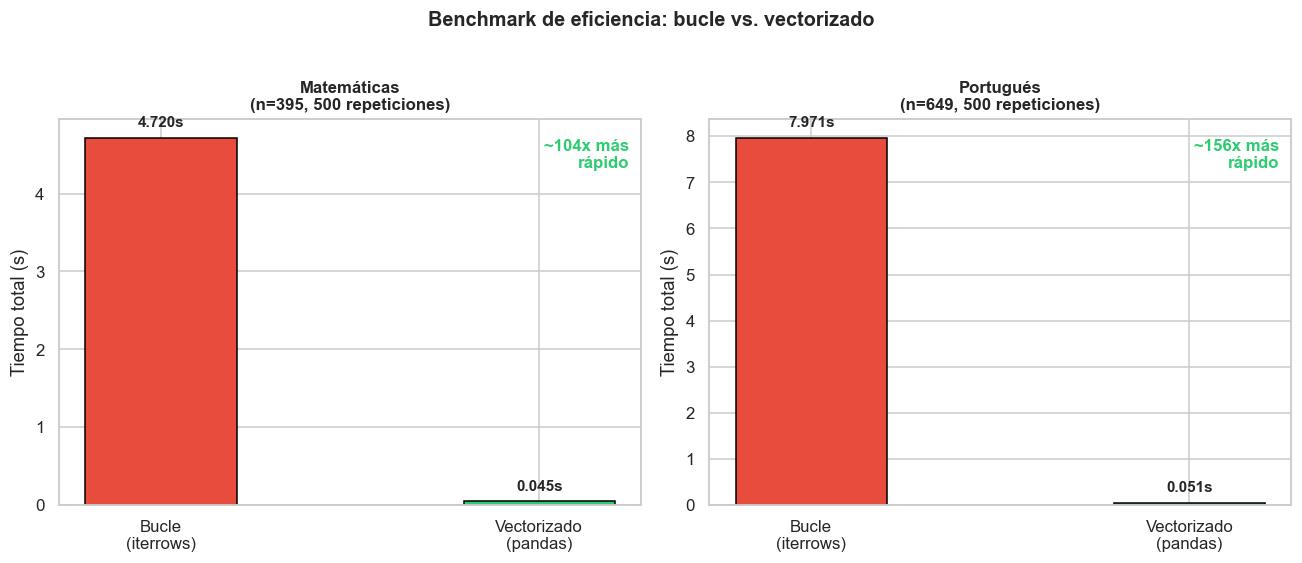


Interpretación:
  Ambas implementaciones comparten complejidad asintótica O(n), pero la versión
  vectorizada es órdenes de magnitud más rápida porque ejecuta el bucle en código
  compilado (C/NumPy) en lugar del intérprete de Python. Al pasar de Matemáticas
  (395 filas) a Portugués (649 filas), el tiempo del bucle escala linealmente
  mientras que el vectorizado apenas varía, evidenciando la ventaja de Pandas para
  grandes volúmenes de datos.

  Decisión técnica: se adopta la implementación vectorizada en todo el pipeline.



In [32]:
# ── Visualización comparativa de los benchmarks ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colores = ["#E74C3C", "#2ECC71"]

for ax, (nombre, datos) in zip(axes, resultados_bench.items()):
    barras = ax.bar(
        ["Bucle\n(iterrows)", "Vectorizado\n(pandas)"],
        [datos['t_bucle'], datos['t_vec']],
        color=colores, width=0.4, edgecolor='black'
    )
    for bar, val in zip(barras, [datos['t_bucle'], datos['t_vec']]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + datos['t_bucle'] * 0.02,
                f"{val:.3f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f"{nombre}\n(n={datos['n_filas']}, {N} repeticiones)",
                 fontsize=11, fontweight='bold')
    ax.set_ylabel("Tiempo total (s)")
    ax.text(0.98, 0.95, f"~{datos['aceleracion']:.0f}x más\nrápido",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=11, color='#2ECC71', fontweight='bold')

plt.suptitle("Benchmark de eficiencia: bucle vs. vectorizado",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../data/processed/F4/', exist_ok=True)
plt.savefig('../data/processed/F4/fig_benchmark_eficiencia.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
Interpretación:
  Ambas implementaciones comparten complejidad asintótica O(n), pero la versión
  vectorizada es órdenes de magnitud más rápida porque ejecuta el bucle en código
  compilado (C/NumPy) en lugar del intérprete de Python. Al pasar de Matemáticas
  (395 filas) a Portugués (649 filas), el tiempo del bucle escala linealmente
  mientras que el vectorizado apenas varía, evidenciando la ventaja de Pandas para
  grandes volúmenes de datos.

  Decisión técnica: se adopta la implementación vectorizada en todo el pipeline.
""")

### 4.5 Diseño estructurado y recursividad

El algoritmo recursivo **Merge Sort** (implementado en F3 en `functions.py`) se aplica aquí con un análisis de complejidad más detallado y una comparativa adicional contra `sorted()` de Python —que usa TimSort, O(n log n)— para mostrar que ambos convergen en resultado pero difieren en rendimiento práctico por las constantes de implementación.

**Análisis de complejidad de merge_sort:**
- **Tiempo:** O(n log n) — cada nivel de recursión procesa n elementos; hay log₂(n) niveles.
- **Espacio:** O(n) — se crean listas auxiliares en cada nivel de combinación.
- **Caso base:** lista de 0 o 1 elementos → ya ordenada, retorna sin llamada recursiva.
- **Caso recursivo:** divide a la mitad → ordena cada parte → combina. El problema se reduce en cada llamada, garantizando terminación.

In [33]:
# ============================================================
# RECURSIVIDAD: Merge Sort aplicado al dataset
# ============================================================

# ── Ordenar G3 de ambas asignaturas ──────────────────────────
g3_mat = prep_mat.df['G3'].dropna().tolist()
g3_por = prep_por.df['G3'].dropna().tolist()

print("── Matemáticas — G3 (primeros 39 valores) ──")
print("  Original :", g3_mat[:39])
print("  Ordenado :", merge_sort(g3_mat)[:39])

print("\n── Portugués — G3 (primeros 20 valores) ──")
print("  Original :", g3_por[:20])
print("  Ordenado :", merge_sort(g3_por)[:20])

# ── Validación contra sorted() ───────────────────────────────
assert merge_sort(g3_mat) == sorted(g3_mat), "Error en Merge Sort — Matemáticas"
assert merge_sort(g3_por) == sorted(g3_por), "Error en Merge Sort — Portugués"
print("\n✓ Verificación: merge_sort produce el mismo resultado que sorted().")

# ── Benchmark merge_sort vs sorted ───────────────────────────
N_ms = 200
t_merge = timeit.timeit(lambda: merge_sort(g3_por[:]), number=N_ms)
t_sorted = timeit.timeit(lambda: sorted(g3_por[:]), number=N_ms)

print(f"\nBenchmark sobre G3 Portugués (n={len(g3_por)}, {N_ms} repeticiones):")
print(f"  merge_sort (Python puro): {t_merge:.4f} s")
print(f"  sorted (TimSort en C)   : {t_sorted:.4f} s")
print(f"  sorted es ~{t_merge/t_sorted:.0f}x más rápido")
print("""
Interpretación: ambos son O(n log n), pero sorted() usa TimSort implementado
en C, lo que lo hace mucho más rápido en la práctica. merge_sort aquí tiene
valor pedagógico: ilustra el patrón recursivo divide-y-vencerás de forma
explícita y legible.""")

── Matemáticas — G3 (primeros 39 valores) ──
  Original : [6, 6, 10, 15, 10, 15, 11, 6, 19, 15, 9, 12, 14, 11, 16, 14, 14, 10, 5, 10, 15, 15, 16, 12, 8, 8, 11, 15, 11, 11, 12, 17, 16, 12, 15, 6, 18, 15, 11]
  Ordenado : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4]

── Portugués — G3 (primeros 20 valores) ──
  Original : [11, 11, 12, 14, 13, 13, 13, 13, 17, 13, 14, 13, 12, 13, 15, 17, 14, 14, 7, 12]
  Ordenado : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 5, 6, 6, 6]

✓ Verificación: merge_sort produce el mismo resultado que sorted().

Benchmark sobre G3 Portugués (n=649, 200 repeticiones):
  merge_sort (Python puro): 0.1858 s
  sorted (TimSort en C)   : 0.0031 s
  sorted es ~60x más rápido

Interpretación: ambos son O(n log n), pero sorted() usa TimSort implementado
en C, lo que lo hace mucho más rápido en la práctica. merge_sort aquí tiene
valor pedagógico: ilustra el patrón recursivo divide-y-vencerás de fo